# TP : Comprendre la Convolution Transposée

Ce TP vous permet d'explorer le mécanisme de la convolution transposée (également appelée déconvolution ou convolution inverse), une opération fondamentale dans les architectures de réseaux génératifs et de segmentation sémantique comme les U-Net ou les autoencodeurs.

L'objectif principal est de comprendre comment une convolution transposée permet d'augmenter la résolution spatiale d'une matrice d'entrée.

Vous implémenterez manuellement cette opération étape par étape, avant de la comparer avec l'implémentation PyTorch (`ConvTranspose2d`).

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

### Fonction de visualisation de matrices

La fonction `plot_matrix_with_selection(matrix, title, sel_ind, sel_shape)` permet de visualiser une matrice avec un rectangle de sélection :

- Afficher la matrice sous forme de grille avec les valeurs inscrites dans chaque case
- Tracer un rectangle bleu autour d'une zone rectangulaire spécifique définie par `sel_ind` (coordonnées du coin supérieur gauche) et `sel_shape` (hauteur et largeur du rectangle)
- Ajouter un titre au graphique
- Utiliser une grille en pointillés gris pour délimiter les cases
- Dimensionner la figure proportionnellement à la taille de la matrice

In [24]:
def plot_matrix_with_selection(matrix, title="Matrix", sel_ind=(0, 0), sel_shape=(0, 0)):
    """
    Affiche une matrice avec un rectangle autour d'une sous-matrice spécifiée.

    Args:
        matrix (np.ndarray): La matrice à afficher.
        rect_ind (tuple): (row, col) coordonnées du coin supérieur gauche du rectangle.
        rect_shape (tuple): (hauteur, largeur) du rectangle.
        title (str, optional): Titre du graphique.
    """
    fig, ax = plt.subplots(figsize=tuple(np.array(matrix.shape) / 2.2))

    if title:
        ax.set_title(title, fontsize=16)

    nrows, ncols = matrix.shape
    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect('equal', adjustable='box')

    for i in range(nrows + 1):
        ax.axhline(i, color='grey', linestyle=':', linewidth=1)
    for j in range(ncols + 1):
        ax.axvline(j, color='grey', linestyle=':', linewidth=1)

    for i in range(nrows):
        for j in range(ncols):
            ax.text(j + 0.5, nrows - (i + 0.5), str(matrix[i, j]),
                    ha='center', va='center', fontsize=12, fontweight='light')

    row, col = sel_ind
    rect_height, rect_width = sel_shape
    rect = Rectangle((col, nrows - row - rect_height), rect_width, rect_height,
                     linewidth=3, edgecolor='blue', facecolor='none')
    ax.add_patch(rect)

    ax.axis('off')
    plt.show()


### Définir une matrice d'entrée simple

Créez une matrice d'entrée `input` de taille 2×2 contenant les valeurs `[[2, 1], [0, 3]]`.

Utilisez la fonction `plot_matrix_with_selection` pour la visualiser sans aucune sélection (en mettant `sel_ind=(0,0)` et `sel_shape=(0,0)`).

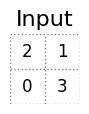

In [25]:
input = np.array([[2, 1], [0, 3]])
sel_shape=(0,0)
sel_ind=(0,0)

plot_matrix_with_selection(input,"Input",sel_ind,sel_shape)

### Définir le noyau de convolution

Créez un noyau de convolution `kernel` de taille 2×2 contenant uniquement des 1 (`[[1, 1], [1, 1]]`).

Affichez ensuite ce noyau avec la fonction de visualisation en mettant en évidence sa surface (le rectangle de sélection doit couvrir l'ensemble du noyau).

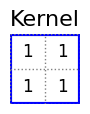

In [26]:
kernel = np.array([[1, 1], [1, 1]])

k_rows, k_cols = kernel.shape

plot_matrix_with_selection(kernel,"Kernel",sel_ind,(k_rows,k_cols))

### Initialiser la matrice de sortie

Calculez la taille de la matrice de sortie pour une convolution transposée.

La formule est : `output_size = input_size + kernel_size - 1` pour chaque dimension.

Créez ensuite une matrice `output_manual` initialisée à zéro avec cette taille, puis visualisez-la.

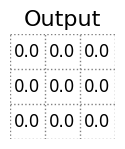

In [27]:
input_rows,input_cols=input.shape;
output_size = (input_rows+k_rows-1,input_cols+k_cols-1)
output_manual = np.zeros(output_size)
plot_matrix_with_selection(output_manual,"Output",sel_ind=(0,0),sel_shape=(0,0))

### Calculer la contribution du premier élément

Pour comprendre le mécanisme de la convolution transposée, traitez le premier élément de l'entrée (position `[0, 0]`). Procédez en plusieurs étapes visualisées :

- Affichez l'élément sélectionné de `input` (position `[0, 0]`)
- Affichez le noyau de convolution
- Calculez le "upscaling" : multipliez la valeur de `input[0, 0]` par le noyau entier (multiplication scalaire-matrice)
- Visualisez le résultat de cette multiplication

Cette opération illustre comment chaque élément de l'entrée est "étalé" selon la forme du noyau.

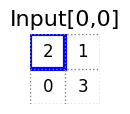

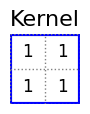

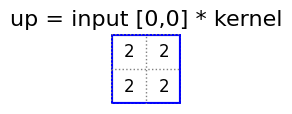

In [28]:
row, col = 0, 0

plot_matrix_with_selection(input, f"Input[{row},{col}]",sel_ind,(1,1))

plot_matrix_with_selection(kernel,"Kernel",sel_ind,(k_rows,k_cols))

upscaling = input[0][0]*kernel
plot_matrix_with_selection(upscaling, title=f"up = input [{row},{col}] * kernel", sel_ind=(0,0), sel_shape=(k_rows, k_cols))

### Visualiser la zone cible dans la sortie

Affichez la matrice de sortie en mettant en évidence la zone cible où le résultat du "upscaling" calculé précédemment va être ajouté.

Cette zone commence à la position `[row, col]` et a la même taille que le noyau.

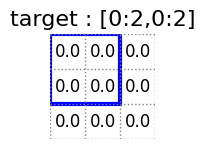

In [29]:
plot_matrix_with_selection(output_manual, f"target : [{row}:{row+k_rows},{col}:{col+k_cols}]",(row,col),(k_rows,k_cols))

### Ajouter la contribution à la sortie

Additionnez le résultat du "upscaling" à la zone cible de la matrice de sortie.

Notez que l'opération est une **addition** et non un remplacement : c'est ainsi que les contributions des différents éléments d'entrée se superposent dans les zones de chevauchement.

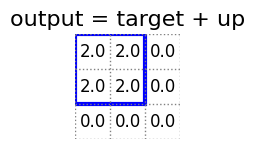

In [30]:
output_manual[row:row+k_rows,col:col+k_cols]=output_manual[row:row+k_rows,col:col+k_cols]+upscaling
plot_matrix_with_selection(output_manual, title=f"output = target + up", sel_ind=(row,col), sel_shape=(k_rows,k_cols))

### Traiter le deuxième élément de l'entrée

Répétez les mêmes étapes pour le deuxième élément de l'entrée, situé en position `[0, 1]` :

- Visualisez l'élément sélectionné dans `input`
- Affichez le noyau
- Calculez le "upscaling" en multipliant `input[0, 1]` par le noyau
- Affichez la zone cible dans la sortie actuelle (qui contient déjà la contribution du premier élément)
- Additionnez le nouveau "upscaling" à cette zone
- Visualisez le résultat final

Observez comment les contributions se superposent dans la zone de chevauchement (colonne 1 de la sortie).

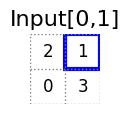

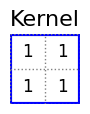

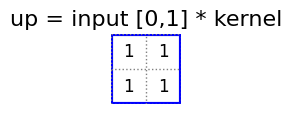

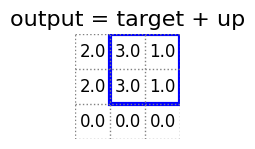

In [31]:
row = 0
col = 1

plot_matrix_with_selection(input, f"Input[{row},{col}]",(row,col),(1,1))

plot_matrix_with_selection(kernel,"Kernel",(0,0),(k_rows,k_cols))

upscaling = input[row][col]*kernel
plot_matrix_with_selection(upscaling, title=f"up = input [{row},{col}] * kernel", sel_ind=(0,0), sel_shape=(k_rows, k_cols))
output_manual[row:row+k_rows,col:col+k_cols]+=upscaling
plot_matrix_with_selection(output_manual, title=f"output = target + up", sel_ind=(row,col), sel_shape=(k_rows,k_cols))

## Généraliser l'approche avec une fonction

Vous avez maintenant compris le principe : il faut répéter ces opérations pour tous les éléments de l'entrée. Créez une fonction générique pour automatiser ce processus.

### Implémenter la convolution transposée manuelle

Implémentez la fonction `manual_conv_transpose2d(input_arr, kernel_arr, plot=True)` qui réalise une convolution transposée complète. Cette fonction doit :

- Initialiser une matrice de sortie
- Parcourir tous les éléments de l'entrée
    - Pour chaque élément, calculer le "upscaling" (élément × noyau) et l'ajouter à la zone appropriée de la sortie
- Si `plot=True`, visualiser chaque étape intermédiaire (élément traité, upscaling, zone cible, résultat)
- Retourner la matrice de sortie finale

La fonction doit fonctionner sans utiliser PyTorch et sans biais.

In [32]:
def manual_conv_transpose2d(input_arr, kernel_arr, plot=True):
    """
    Effectue une convolution transposée manuelle (sans PyTorch et sans biais) entre input_arr et kernel_arr,
    en affichant les étapes avec plot_matrix_with_rectangle si plot=True.

    Args:
        input_arr (np.ndarray): matrice d'entrée.
        kernel_arr (np.ndarray): noyau de convolution.
        plot (bool): si True, affiche les étapes avec plot_matrix_with_rectangle.

    Returns:
        np.ndarray: résultat de la convolution transposée.
    """
    i_rows,i_cols=input_arr.shape;
    k_rows,k_cols=kernel_arr.shape;
    output_size = (i_rows+k_rows-1,i_cols+k_cols-1)
    output = np.zeros(output_size)

    for i in range(i_rows):
      for j in range(i_cols):
        up = input_arr[i][j]*kernel
        output[i:i+k_rows,j:j+k_cols]=output[i:i+k_rows,j:j+k_cols]+up
        if plot:
          plot_matrix_with_selection(input_arr, f"Input[{i},{j}]",(i,j),(1,1))
          plot_matrix_with_selection(kernel,"Kernel",(0,0),(k_rows,k_cols))
          plot_matrix_with_selection(up, title=f"up = input [{i},{j}] * kernel", sel_ind=(0,0), sel_shape=(k_rows, k_cols))
          plot_matrix_with_selection(output, title=f"output = target + up", sel_ind=(i,j), sel_shape=(k_rows,k_cols))
    return output


### Tester la fonction manuelle avec visualisation

Utilisez la fonction `manual_conv_transpose2d` avec `plot=True` pour traiter la matrice d'entrée 2×2 initiale avec le noyau 2×2.

Observez toutes les étapes de calcul et vérifiez que le résultat final est cohérent avec vos attentes.

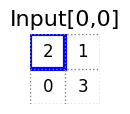

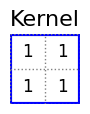

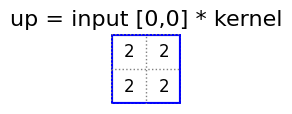

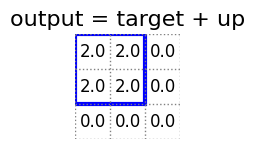

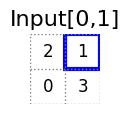

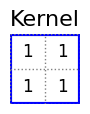

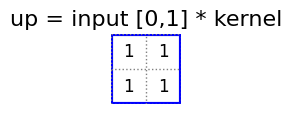

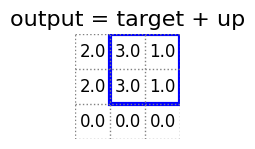

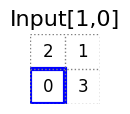

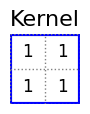

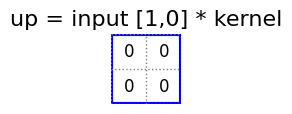

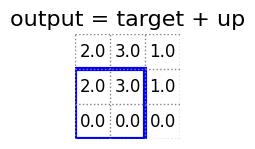

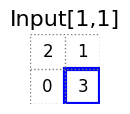

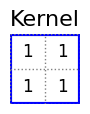

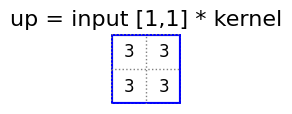

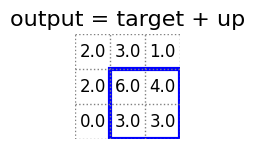

Sortie de la convolution transposée manuelle :
 [[2. 3. 1.]
 [2. 6. 4.]
 [0. 3. 3.]]


In [33]:
output_manual = manual_conv_transpose2d(input, kernel, plot=True)
print("Sortie de la convolution transposée manuelle :\n", output_manual)

### Comparer avec l'implémentation PyTorch

Vérifiez que votre implémentation manuelle est correcte en la comparant avec `torch.nn.ConvTranspose2d`. Pour cela :

- Créez une couche `ConvTranspose2d` avec
    - 1 canal d'entrée,
    - 1 canal de sortie,
    - un noyau de taille 2×2,
    - un stride de 1,
    - un padding de 0 et sans biais (`bias=False`)
- Assignez manuellement les poids du noyau à cette couche (utilisez `torch.nn.Parameter` et les bonnes dimensions : `[out_channels, in_channels, height, width]`)
- Convertissez votre entrée en tenseur PyTorch avec les dimensions appropriées
- Appliquez la couche de convolution transposée
- Comparez les deux résultats avec `np.array_equal`

Les deux sorties doivent être identiques.

In [37]:
conv_up = torch.nn.ConvTranspose2d(1,1,(2,2),bias=False,stride=1,padding=0)
conv_up.weight = torch.nn.Parameter(torch.tensor(kernel, dtype=torch.float32).unsqueeze(0).unsqueeze(0))

input_tensor = torch.tensor(input,dtype=torch.float32).unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    output_tensor = conv_up(input_tensor)
    output_from_torch = output_tensor.numpy().squeeze()

print("Sortie de la convolution transposée manuelle :\n", output_manual)
print("Sortie de ConvTranspose2d de PyTorch :\n", output_from_torch)

print("Les deux sorties sont-elles exactement égales ?", np.array_equal(output_manual, output_from_torch))

Sortie de la convolution transposée manuelle :
 [[2. 3. 1.]
 [2. 6. 4.]
 [0. 3. 3.]]
Sortie de ConvTranspose2d de PyTorch :
 [[2. 3. 1.]
 [2. 6. 4.]
 [0. 3. 3.]]
Les deux sorties sont-elles exactement égales ? True


### Tester avec des matrices plus complexes

Pour valider davantage votre implémentation, testez-la avec des matrices de tailles différentes :

- Créez une matrice d'entrée 4×3 avec des valeurs variées
- Créez un noyau 3×2 avec des valeurs non uniformes
- Appliquez votre fonction manuelle avec `plot=False`
- Affichez le résultat obtenu

In [38]:
# plus compliqué
input = np.array([[2, 1, 0],
                  [0, 3, 1],
                  [1, 2, 2],
                  [0, 3, 1]])
kernel = np.array([[1, 2],
                   [3, 4],
                   [5, 6]])
output_manual = manual_conv_transpose2d(input,kernel,False)
print("Sortie de la convolution transposée manuelle :\n", output_manual)

Sortie de la convolution transposée manuelle :
 [[ 2.  5.  2.  0.]
 [ 6. 14. 11.  2.]
 [11. 30. 27.  8.]
 [ 3. 28. 44. 16.]
 [ 5. 25. 37. 16.]
 [ 0. 15. 23.  6.]]


### Valider avec PyTorch

Répétez la comparaison avec PyTorch pour ces nouvelles matrices.

In [39]:
# la même avec PyTorch

conv_up = torch.nn.ConvTranspose2d(1,1,(kernel.shape[0],kernel.shape[1]),bias=False,stride=1,padding=0)
conv_up.weight = torch.nn.Parameter(torch.tensor(kernel, dtype=torch.float32).unsqueeze(0).unsqueeze(0))

input_tensor = torch.tensor(input,dtype=torch.float32).unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    output_tensor = conv_up(input_tensor)
    output_from_torch = output_tensor.numpy().squeeze()

print("Sortie de la convolution transposée manuelle :\n", output_manual)
print("Sortie de ConvTranspose2d de PyTorch :\n", output_from_torch)

print("Les deux sorties sont-elles exactement égales ?", np.array_equal(output_manual, output_from_torch))

Sortie de la convolution transposée manuelle :
 [[ 2.  5.  2.  0.]
 [ 6. 14. 11.  2.]
 [11. 30. 27.  8.]
 [ 3. 28. 44. 16.]
 [ 5. 25. 37. 16.]
 [ 0. 15. 23.  6.]]
Sortie de ConvTranspose2d de PyTorch :
 [[ 2.  5.  2.  0.]
 [ 6. 14. 11.  2.]
 [11. 30. 27.  8.]
 [ 3. 28. 44. 16.]
 [ 5. 25. 37. 16.]
 [ 0. 15. 23.  6.]]
Les deux sorties sont-elles exactement égales ? True
